In [1]:
# No sys.path hacks needed anymore!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import your custom package
from cooltrack.constants import INDEPENDENT_DIMS
from cooltrack.data_loader import load_and_clean_grid_pandas
from cooltrack.models import ThermalEvolutionModels
from cooltrack.integrator import CoolingIntegrator
from cooltrack.initial_conditions import InitialConditions


# Adjust this path based on where the notebook is relative to your data
GRID_FILE_PATH = "../../data/HADES_grid/hades_processed_grid.parquet"

In [2]:
print("Using src.data_loader to fetch data...")
# The data loader handles all the PyArrow filtering and unit conversions automatically
df = load_and_clean_grid_pandas(GRID_FILE_PATH)

# Let's use a smaller slice of the data so training is instant for our plot test
df_test = df[df['mass_Mj'] <= 10].copy()
print(f"Ready with {len(df_test):,} rows.")

2026-02-23 00:54:49,538 - INFO - Loading filtered parquet file: ../data/hades_processed_grid.parquet...


Using src.data_loader to fetch data...


2026-02-23 00:54:49,781 - INFO - Grid loaded successfully. Final shape: (91613, 13)


Ready with 89,518 rows.


In [3]:
print("Training models using src.models.ThermalEvolutionModels...")
ml_engine = ThermalEvolutionModels()

# This trains both the T_int and dS/dt models and stores them inside ml_engine
ml_engine.train_models(df_test, tune_hyperparameters=False)

print("Models trained and ready!")

2026-02-23 00:54:56,328 - INFO - Training T_int state model...


Training models using src.models.ThermalEvolutionModels...


2026-02-23 00:54:58,441 - INFO - T_int model R^2: 0.9667
2026-02-23 00:54:58,460 - INFO - Training baseline dS/dt model...
2026-02-23 00:55:00,807 - INFO - dS/dt model test R^2: 0.8424


Models trained and ready!


2026-02-23 00:56:47,341 - INFO - Loaded initial condition interpolators from 4 files.


Integrating a track using exact initial conditions...
Integrating from S0 = 79607.1 down to 12601.1 J/K/kg...


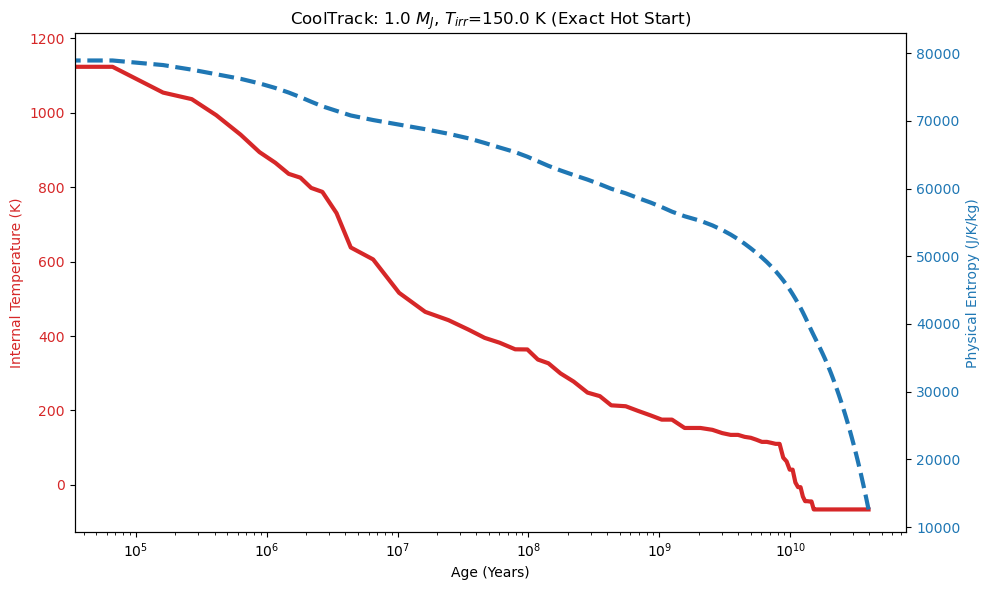

In [7]:
print("Integrating a track using exact initial conditions...")


# 1. Setup the Integrator
integrator = CoolingIntegrator(ml_engine)

# 2. Setup the Initial Conditions (Hot/Cold starts)
AGE_DATA_PATH = "../data/age_data/"  # Update this path if needed!
init_cond = InitialConditions(AGE_DATA_PATH)

# Pick a target planet to plot (e.g., 1 Jupiter Mass, 500K Irradiation)
test_mass = 1.0
test_tirr = 150.0

# Find a matching row in our dataset to get realistic fixed parameters (Core, Met, etc.)
planet_row = df_test[(np.isclose(df_test['mass_Mj'], test_mass, atol=0.1)) & 
                     (np.isclose(df_test['T_irr'], test_tirr, atol=10))].iloc[0]

# --- THE BIG UPGRADE ---
# Use the new module to get the exact hot-start entropy for a 1 Jupiter mass planet
# bin_index 19 out of 20 means a very "Hot Start"
s_hot_start = init_cond.get_starting_physical_entropy(test_mass, bin_index=19, n_bins=20)

# For the end of the track, we can still just integrate down to the coldest point in the grid
s_cold_end = df_test['S_physical'].min()   

print(f"Integrating from S0 = {s_hot_start:.1f} down to {s_cold_end:.1f} J/K/kg...")

# Calculate the full track!
ages, entropies = integrator.calculate_track(planet_row, s_hot_start, s_cold_end)

if ages is not None:
    # Predict T_int at each step to plot the physical temperature
    fixed_params = planet_row[INDEPENDENT_DIMS].values.astype(float)
    t_ints = []
    
    for s in entropies:
        inp = np.append(fixed_params, s).reshape(1, -1)
        t_ints.append(ml_engine.tint_model.predict(inp)[0])

    # --- Plotting ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:red'
    ax1.set_xlabel('Age (Years)')
    ax1.set_ylabel('Internal Temperature (K)', color=color)
    ax1.plot(ages, t_ints, color=color, lw=3)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xscale('log') 
    
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Physical Entropy (J/K/kg)', color=color)  
    ax2.plot(ages, entropies, color=color, lw=3, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"CoolTrack: {test_mass} $M_J$, $T_{{irr}}$={test_tirr} K (Exact Hot Start)")
    fig.tight_layout()  
    plt.show()
else:
    print("Integration failed or returned None.")